In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
import csv
import pandas as pd

file = "creditcard.csv"

# Detect encoding from BOM
with open(file, "rb") as f:
    raw = f.read(200000)

if raw.startswith(b'\xff\xfe') or raw.startswith(b'\xfe\xff'):
    encoding = "utf-16"
elif raw.startswith(b'\xef\xbb\xbf'):
    encoding = "utf-8-sig"
else:
    encoding = "utf-8"

# Decode sample and detect delimiter
sample = raw.decode(encoding, errors="strict")
dialect = csv.Sniffer().sniff(sample, delimiters=",;\t|")

print("Encoding:", encoding)
print("Delimiter:", repr(dialect.delimiter))

# Load WITHOUT skipping rows
df = pd.read_csv(
    file,
    encoding=encoding,
    sep=dialect.delimiter,
    quotechar='"',
    engine="python",
    on_bad_lines="error"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc5 in position 6: invalid continuation byte

In [10]:
!wget -q "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv" -O creditcard_clean.csv

df = pd.read_csv("creditcard_clean.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Dataset loaded successfully!
Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Fraud Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


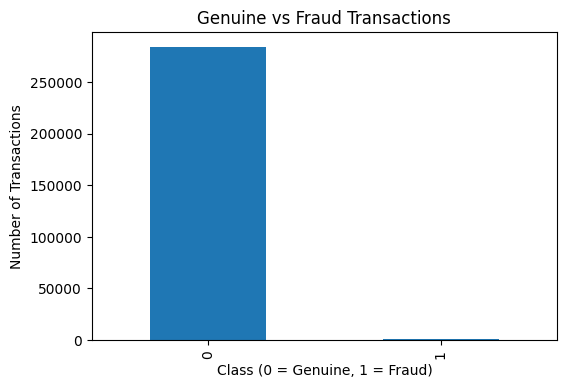

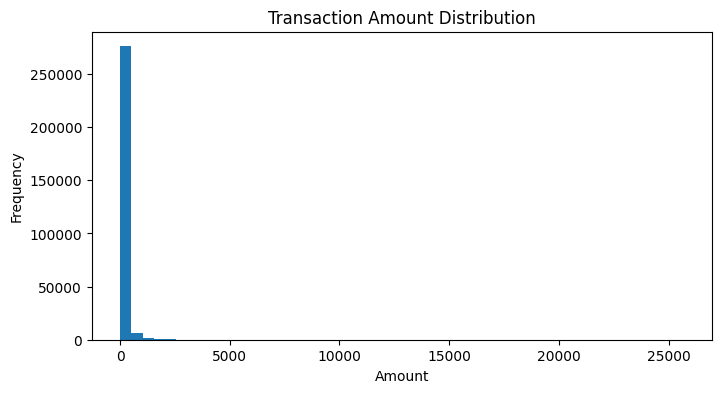

Model Accuracy: 0.9991397773954567

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56851    13]
 [   36    62]]

CONCLUSION:
The Credit Card Fraud Detection dataset was analyzed to identify fraudulent
transactions. The dataset contains genuine and fraudulent transactions.
Exploratory Data Analysis was performed using fraud distribution and
transaction amount visualizations. A Logistic Regression model was trained
to classify transactions as genuine or fraudulent. Model performance was
evaluated using accuracy, classification report and confusion matrix.



In [11]:
# FRAUD DETECTION - FINAL ANALYSIS

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Check fraud distribution
print("Fraud Distribution:")
print(df["Class"].value_counts())

# Graph 1: Genuine vs Fraud
plt.figure(figsize=(6,4))
df["Class"].value_counts().plot(kind="bar")
plt.title("Genuine vs Fraud Transactions")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

# Graph 2: Transaction Amount
plt.figure(figsize=(8,4))
plt.hist(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Prepare data
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Results
print("Model Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Conclusion
print("""
CONCLUSION:
The Credit Card Fraud Detection dataset was analyzed to identify fraudulent
transactions. The dataset contains genuine and fraudulent transactions.
Exploratory Data Analysis was performed using fraud distribution and
transaction amount visualizations. A Logistic Regression model was trained
to classify transactions as genuine or fraudulent. Model performance was
evaluated using accuracy, classification report and confusion matrix.
""")